In [ ]:
# Enable autoreload of local Python modules (e.g., models)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time
import json
import sys

import matplotlib.pyplot as plt
import seaborn as sns

# local imports

from models.models import DecoderOnlyTransformer
from util.data_loader import load_data, encode, decode, get_batch
from util.optimization import train_step, loss_and_metrics, create_train_state
from util.generation import generate_tokens

In [10]:
# initialize jax random key
master_key = jax.random.PRNGKey(0)

In [ ]:
# load dataset
train_data, test_data, ctoi, itoc, vocab_size = load_data(encoded_path='data/encoded.pkl')

In [ ]:
# sanity check: display a few random characters from the training text
'''
T = 128
train_text = decode(train_data, itoc)
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()
 '''

 bashkir chechen kazakh tajik etc after one nine two eight their script became latin then later cyrillic computers and the arabi

x son of y or x daughter of y hence his original name halld r gu j nsson meant halld r son of gu j n just as his own parents nam

d series profits so cleveland players had a financial interest in keeping greenberg from hitting home runs for his own part gree

 one nine three eight however the purge had become so extensive that it was damaging the infrastructure of the soviet state its 

less than two three countries lacrosse world championships have been dominated by the united states particularly in the men s ga



#### Parameter

In [12]:
# Model parameters
d_model = 256
n_heads = 4
n_layers = 4 # Based on model_arch experiment
dropout_rate = 0.1

B, T = 256, 128
niter = 100000

##### Model

In [13]:
master_key, init_key = jax.random.split(master_key)
model, params = create_train_state(init_key, vocab_size=vocab_size, d_model=d_model,  n_layers=n_layers, n_heads=n_heads, max_len=T, dropout_rate=dropout_rate)

##### Optimizer

In [12]:
scheduler = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=5e-3,
    warmup_steps=2000, # 1-2% of niter
    decay_steps=niter,
    end_value=1e-4
)
tx = optax.adamw(learning_rate=scheduler, b1=0.9, b2=0.95, weight_decay=0.1)
opt_state = tx.init(params)
print(f"Initialized optimizer: AdamW with Warmup Cosine Decay")

Initialized optimizer: AdamW with Warmup Cosine Decay


#### Train

In [13]:
loss_history = []
time_history = []
test_time_history = []
test_loss_history = []
train_acc_history = []
train_acc_last_history = []
test_acc_history = []
test_acc_last_history = []

# append into results_summary
results_summary = []

In [14]:
cur_iter = 0

start_time = time.time()
while True:

    # get batch
    input, target = get_batch(train_data, B, T)

    # Training step
    master_key, dropout_key = jax.random.split(master_key)
    params_new, opt_state_new, metrics = train_step(model, params, opt_state, input, target, tx, key=dropout_key)

    # uodate params and opt_state
    params = params_new
    opt_state = opt_state_new
    # get metrics
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']

    # append to history
    loss_history.append(loss)
    time_history.append(time.time() - start_time)
    train_acc_history.append(acc)
    train_acc_last_history.append(acc_last)

    # Evaluate on test set regularly
    if cur_iter % (niter // 50) == 0 or cur_iter == niter - 1:
        time_since_start = time.time() - start_time
        B_test, T_test = 1024, 64 # larger batch size for evaluation
        test_input, test_target = get_batch(test_data, B_test, T_test)
        test_logits = model.apply({'params': params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        test_loss_history.append(test_loss)
        test_time_history.append(time_since_start)
        test_acc_history.append(test_acc)
        test_acc_last_history.append(test_acc_last)
        print(f"iteration {cur_iter:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()

    cur_iter += 1
    if cur_iter >= niter:
        results = {
            'train_loss_history': loss_history,
            'train_time_history': time_history,
            'test_loss_history': test_loss_history,
            'test_time_history': test_time_history,
            'train_acc_history': train_acc_history,
            'train_acc_last_history': train_acc_last_history,
            'test_acc_history': test_acc_history,
            'test_acc_last_history': test_acc_last_history,
        }
        results_summary.append(results)
        break

iteration 0  time: 10.9 seconds
	 	 loss(train :: test): 3.5985 :: 3.5724
	 	 accuracy (train :: test): 4.2% :: 4.7%
	 	 accuracy (last character) (train :: test): 5.1% :: 3.8%

iteration 2_000  time: 574.7 seconds
	 	 loss(train :: test): 1.3204 :: 1.3537
	 	 accuracy (train :: test): 59.0% :: 57.9%
	 	 accuracy (last character) (train :: test): 59.0% :: 58.8%

iteration 4_000  time: 1140.7 seconds
	 	 loss(train :: test): 1.2396 :: 1.2933
	 	 accuracy (train :: test): 61.2% :: 59.6%
	 	 accuracy (last character) (train :: test): 62.5% :: 59.5%

iteration 6_000  time: 1705.1 seconds
	 	 loss(train :: test): 1.2287 :: 1.2506
	 	 accuracy (train :: test): 61.6% :: 60.8%
	 	 accuracy (last character) (train :: test): 60.5% :: 63.7%

iteration 8_000  time: 2268.7 seconds
	 	 loss(train :: test): 1.2174 :: 1.2494
	 	 accuracy (train :: test): 62.0% :: 61.1%
	 	 accuracy (last character) (train :: test): 57.8% :: 64.5%

iteration 10_000  time: 2834.2 seconds
	 	 loss(train :: test): 1.2117 

KeyboardInterrupt: 

save results

In [15]:
results = {
            'train_loss_history': loss_history,
            'train_time_history': time_history,
            'test_loss_history': test_loss_history,
            'test_time_history': test_time_history,
            'train_acc_history': train_acc_history,
            'train_acc_last_history': train_acc_last_history,
            'test_acc_history': test_acc_history,
            'test_acc_last_history': test_acc_last_history,
        }
results_summary.append(results)

In [16]:
# Convert JAX arrays to lists
def convert_to_list(obj):
    if isinstance(obj, dict):
        return {k: convert_to_list(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_list(item) for item in obj]
    elif isinstance(obj, jax.numpy.ndarray):
        return obj.tolist() # Convert JAX array to Python list
    else:
        return obj

In [17]:
results_serializable = convert_to_list(results_summary)
with open("/content/drive/MyDrive/char_transformer/results/final_model_results.json", "w") as f:
      json.dump(results_serializable, f)

Analyse results

In [39]:
with open("results/final_model_results.json", "r") as f:
      results = json.load(f)

results = results[0]

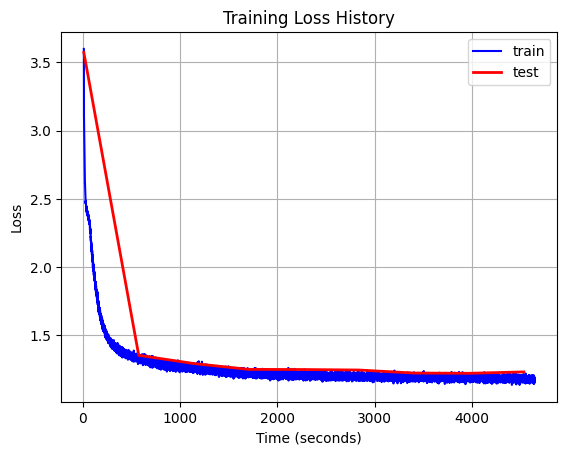

In [40]:
# plot the loss history
plt.plot(results['train_time_history'], results['train_loss_history'], '-', label='train', color="blue")
plt.plot(results['test_time_history'], results['test_loss_history'], '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

In [44]:
run_results = results
avg_train_acc = np.mean(run_results['train_acc_history'])
avg_test_acc = np.mean(run_results['test_acc_history'])
avg_train_acc_last = np.mean(run_results['train_acc_last_history'])
avg_test_acc_last = np.mean(run_results['test_acc_last_history'])
avg_train_loss = np.min(run_results['train_loss_history'])
avg_test_loss = np.min(run_results['test_loss_history'])
max_train_acc = np.max(run_results['train_acc_history'])
max_test_acc = np.max(run_results['test_acc_history'])
max_train_acc_last = np.max(run_results['train_acc_last_history'])
max_test_acc_last = np.max(run_results['test_acc_last_history'])

print(f"Average Training Loss: {avg_train_loss:.4f}")
print(f"Average Test Loss: {avg_test_loss:.4f}")
print(f"Average Training Accuracy: {avg_train_acc:.4f}")
print(f"Average Test Accuracy: {avg_test_acc:.4f}")
print(f"Max Training Accuracy: {max_train_acc:.4f}")
print(f"Max Test Accuracy: {max_test_acc:.4f}")
print(f"Average Training Accuracy (Last Char): {avg_train_acc_last:.4f}")
print(f"Average Test Accuracy (Last Char): {avg_test_acc_last:.4f}")
print(f"Max Training Accuracy (Last Char): {max_train_acc_last:.4f}")
print(f"Max Test Accuracy (Last Char): {max_test_acc_last:.4f}")

Average Training Loss: 1.1366
Average Test Loss: 1.2218
Average Training Accuracy: 0.6047
Average Test Accuracy: 0.5444
Max Training Accuracy: 0.6445
Max Test Accuracy: 0.6173
Average Training Accuracy (Last Char): 0.6171
Average Test Accuracy (Last Char): 0.5596
Max Training Accuracy (Last Char): 0.7539
Max Test Accuracy (Last Char): 0.6514


generate text

In [31]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
# prompt_int = encode(prompt.lower())
prompt_int = jnp.array([ [ctoi.get(c, vocab_size) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generate_tokens(model, params, rng, prompt_int, gen_len, block_size=64,
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(itoc.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 1000)
generated text:
hello my friend more converted against all the feeling of the death this makes it discovered the number of sources that continued with product similar to their searches the control of a fairy start although the latter s ends with the point can be supported to be black climate of the form of the second way in the two zero th century some of the most common but native erroneous organizations of the religion the presentation of the need for the european community of the president is held and members of the region legislative power in the country left to the united states in one nine seven one although the emperor of the president of the emperor refused to refuse to the republican republic well in germany is a member of the republic of britain regarding the land to consider a republic administration of india the general and political parties of india specific and architecture of the new york city and determines the master and the democratic ru